# Implementing a simple IV estimator in in Probabilistic Programming (PP) using NumPyro

*Hugo Storm, Sep 2029*

___
### Aims of the notebook

- Show how to implement an IV estimator in NumPyro and estimated using Bayesian methods, as an alternative to a 2sls estimation.

- Demonstrate that the PP approach makes the assumption of the estimator very explicit.





In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numpyro.infer import Predictive
import numpyro
import jax
import jax.random as random

import jax.numpy as jnp
import numpyro.distributions as dist
import arviz as az

import numpyro
import numpyro.distributions as dist
from numpyro.diagnostics import print_summary
from numpyro.infer import MCMC, NUTS, Predictive

import statsmodels.api as sm
import statsmodels.formula.api as smf
from graphviz import Digraph
import pandas as pd

from statsmodels.sandbox.regression.gmm import IV2SLS

rng_key = random.PRNGKey(0)

Use the code in the next cell to install graphviz to visualize the DAG:


In [2]:
# !apt-get update
# !apt-get install graphviz
# !pip install graphviz

## Data Generating Process (DGP) for IV model

We assume that there is an unobserved confounder U that affects both the treatment E and the outcome Y. We also assume that there is an instrument Z that affects the treatment E but does not affect the outcome Y directly (only through E). Additionally, we have a set of exogenous variables X that affect the outcome Y but are not related to the treatment E. 


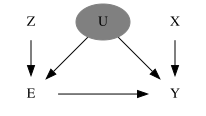

In [3]:
from graphviz import Digraph
# Example using graphviz Digraph https://graphviz.readthedocs.io/en/stable/examples.html
dot = Digraph(engine='neato')
dot.attr('node', style='filled', color='white') # Set color to white to indicate observed/unobserved variables
dot.node('Z', 'Z',pos='0,1!')
dot.node('X', 'X',pos='2,1!')
dot.node('U', 'U',pos='1,1!', color='gray')
dot.node('E', 'E',pos='0,0!')
dot.node('Y', 'Y',pos='2,0!')
dot.edges([('U','Y'),('U','E'),('E','Y'),('X','Y'),('Z','E')])
dot

## Implement a DGP that follows the DAG in the figure. The DGP is defined by the following equations:

$Y_i \sim \mathcal{N}(\mu^Y, \sigma_Y^2)$

$\mu^Y = a^Y + b^Y_X  X_i + b^Y_E  E_i + b^Y_U  U_i$

$\sigma_Y^2 \sim HalfNormal(1)$

$E_i \sim \mathcal{N}(\mu^E, \sigma_E^2)$

$\mu^E = a^E + b^E_Z  Z_i + b^E_U  U_i$

$\sigma_E^2 \sim HalfNormal(1)$

$U_i \sim \mathcal{N}(0,1)$

<!-- - E = aE + bE_Z * Z + bE_U * U + e
- Y = aY + bY_X * X + bY_E * E + bY_U * U + e  -->

In [4]:
def model_fn(X, Z, E=None, Y=None):
    
    # Prior for latent/unobserved variable U
    U = numpyro.sample('U', dist.Normal(0, 1).expand([X.shape[0], 1]))
    
    # Prior for coefficients for the E model
    aE = numpyro.sample('aE', dist.Normal(0, 1))
    bE_Z = numpyro.sample('bE_Z', dist.Normal(0, 1))
    bE_U = numpyro.sample('bE_U', dist.Normal(0, 1))
    # Mean of E, given instrument Z
    mu_E =  aE + bE_Z * Z + bE_U * U
    # Prior for std of E
    sigma_E = numpyro.sample('sigma_E', dist.HalfNormal(1))
    
    # Sample E from its distribution, given Z
    E = numpyro.sample('E', dist.Normal(mu_E, sigma_E), obs=E)
    
    # Prior for coefficients for the Y model
    aY = numpyro.sample('aY', dist.Normal(0, 1))
    bY_X = numpyro.sample('bY_X', dist.Normal(0, 1).expand([X.shape[1],1]))
    bY_E = numpyro.sample('bY_E', dist.Normal(0, 1))
    bY_U = numpyro.sample('bY_U', dist.Normal(0, 1))
    # Mean of Y, given X, E, and U
    mu_Y = aY +  X @ bY_X + bY_E * E + bY_U * U
    # Prior for std of Y
    sigma = numpyro.sample('sigma', dist.HalfNormal(1))
    # Sample Y from its distribution, given X, E, and U
    numpyro.sample('Y', dist.Normal(mu_Y, sigma), obs=Y)


## Sample data from the DGP

Check the "true" coefficents to see how this impacts the estimation of the causal effect of E on Y. 

Particular, see what happens when reducing the effect of the instrument Z on the treatment E (```bE_Z```). 
When this effect is small, the instrument is weak and the IV estimator will be biased.

In [5]:
# Data generation of IV model with 1 instruments and 1 endogenous variables
N = 1000
k_exog = 2
X = np.random.normal(size=(N,k_exog))
Z = np.random.normal(size=(N,1))

coef_true = {
    'aE': 0.5,
    'bE_Z': 1.,
    'bE_U': 1.0,
    'aY': 0.5,
    'bY_X': np.array([[1.0],[1.0]]),
    'bY_E': 1.0,
    'bY_U': -1.0
}

condition_model = numpyro.handlers.condition(model_fn, data=coef_true)
prior_predictive = Predictive(condition_model, num_samples=1)

# prior_predictive = Predictive(model_fn,num_samples=1,)
prior_samples = prior_predictive(rng_key, X=X, Z=Z)
prior_samples.keys()

E = prior_samples['E'][0]
Y = prior_samples['Y'][0]
assert Y.shape == (N,1)
U = prior_samples['U'][0]
aE_true = prior_samples['aE'][0]
bE_Z_true = prior_samples['bE_Z'][0]
bE_U_true = prior_samples['bE_U'][0]
aY_true = prior_samples['aY'][0]
bY_X_true = prior_samples['bY_X'][0]
bY_E_true = prior_samples['bY_E'][0]
bY_U_true = prior_samples['bY_U'][0]




In [6]:
# Save true parameter values in a DataFrame for later comparison with posterior estimates
dfres = pd.DataFrame(np.vstack([bY_X_true,bY_E_true,bY_U_true,aE_true,aY_true,bE_Z_true,bE_U_true]), columns=['true'],
                   index=[f'bY_X[{k}]' for k in range(k_exog)]+['bY_E','bY_U','aE','aY','bE_Z','bE_U'])
dfres

,true
bY_X[0],1.0
bY_X[1],1.0
bY_E,1.0
bY_U,-1.0
aE,0.5
aY,0.5
bE_Z,1.0
bE_U,1.0


## Estimate the IV model using 

Check the estimation output, a key different of the Bayesian model is that we are estimating N latent variables (the unobserved confounder U). 

In [7]:
mcmc = MCMC(NUTS(model_fn, init_strategy=numpyro.infer.init_to_sample), num_warmup=500, num_samples=500, num_chains=1)
mcmc.run(random.PRNGKey(0), X=X, Z=Z, E=E, Y=Y)
azMCMC = az.from_numpyro(mcmc)
mcmc.print_summary(0.89)

sample: 100%|██████████| 1000/1000 [00:28<00:00, 35.14it/s, 63 steps of size 9.81e-02. acc. prob=0.93]



                mean       std    median      5.5%     94.5%     n_eff     r_hat
    U[0,0]      0.74      0.72      0.70     -0.37      1.92     72.18      1.00
    U[1,0]      1.58      0.72      1.67      0.42      2.59     61.49      1.00
    U[2,0]     -0.43      0.67     -0.45     -1.49      0.66    306.43      1.00
    U[3,0]     -0.68      0.64     -0.67     -1.68      0.36    557.98      1.00
    U[4,0]      0.78      0.57      0.78     -0.06      1.74    585.31      1.00
    U[5,0]     -0.37      0.77     -0.41     -1.61      0.78     47.82      1.00
    U[6,0]      0.09      0.68      0.04     -0.94      1.19    303.35      1.00
    U[7,0]     -0.18      0.67     -0.15     -1.22      0.88    515.80      1.00
    U[8,0]      0.76      0.63      0.74     -0.21      1.75    264.33      1.00
    U[9,0]     -1.44      0.60     -1.44     -2.43     -0.61    729.72      1.00
   U[10,0]      0.38      0.64      0.39     -0.77      1.29    574.19      1.00
   U[11,0]     -0.01      0

Save estimated parameters to ```dfres```

In [8]:
for i in range(k_exog):
   dfres.loc[f'bY_X[{i}]','mcmc_mean'] = mcmc.get_samples()['bY_X'][:, i].mean()
dfres.loc['bY_E','mcmc_mean'] = mcmc.get_samples()['bY_E'].mean()
dfres.loc['bY_U','mcmc_mean'] = mcmc.get_samples()['bY_U'].mean()
dfres.loc['aE','mcmc_mean'] = mcmc.get_samples()['aE'].mean()
dfres.loc['aY','mcmc_mean'] = mcmc.get_samples()['aY'].mean()
dfres.loc['bE_Z','mcmc_mean'] = mcmc.get_samples()['bE_Z'].mean()
dfres.loc['bE_U','mcmc_mean'] = mcmc.get_samples()['bE_U'].mean()

## Estimate a simple OLS model as comparison

In [9]:
X_ols = np.hstack([np.ones((N, 1)), X, E])
bOls = np.linalg.inv(X_ols.T@X_ols)@X_ols.T@Y
print('beta OLS manual\n', bOls)

dfres.loc['bY_X[0]','OLS'] = bOls[1][0]
dfres.loc['bY_X[1]','OLS'] = bOls[2][0]
dfres.loc['bY_E','OLS'] = bOls[3][0]
dfres.loc['aY','OLS'] = bOls[0][0]

beta OLS manual
 [[0.62815726]
 [0.9268191 ]
 [0.941779  ]
 [0.7045553 ]]


## Estimate a 2SLS model manually 

See: Verbeek, M. (2008). A guide to modern econometrics, Chichester: John Wiley & Sons, p. 153

In [10]:
# Verify with manual 2SLS (see Verbeek 2008 p. 153)
Ziv = np.hstack([np.ones((N, 1)), X, Z])
invZZ = np.linalg.inv(Ziv.T@Ziv)
XZ = X_ols.T@Ziv
ZX = Ziv.T@X_ols
bIV = np.linalg.inv(XZ@invZZ@ZX)@XZ@invZZ@Ziv.T@Y
print('beta 2sls manual\n',bIV)

dfres.loc['aY','2sls manual'] = bIV[0][0]
dfres.loc['bY_X[0]','2sls manual'] = bIV[1][0]
dfres.loc['bY_X[1]','2sls manual'] = bIV[2][0]
dfres.loc['bY_E','2sls manual'] = bIV[3][0]


beta 2sls manual
 [[0.4677356 ]
 [0.92582715]
 [0.9134079 ]
 [1.072236  ]]


## Estimate a 2SLS model using statsmodels

In [11]:
mod = IV2SLS(Y, np.hstack([np.ones((N, 1)),X,E]), instrument=np.hstack([np.ones((N, 1)),X,Z]))    # Describe model
res = mod.fit()  
print(res.summary()) 

dfres.loc['aY','2sls statsmodels'] = res.params[0]
dfres.loc['bY_X[0]','2sls statsmodels'] = res.params[1]
dfres.loc['bY_X[1]','2sls statsmodels'] = res.params[2]
dfres.loc['bY_E','2sls statsmodels'] = res.params[3]

                          IV2SLS Regression Results                           
Dep. Variable:                      y   R-squared:                       0.331
Model:                         IV2SLS   Adj. R-squared:                  0.329
Method:                     Two Stage   F-statistic:                     153.2
                        Least Squares   Prob (F-statistic):           1.20e-81
Date:                Wed, 16 Sep 2026                                         
Time:                        04:54:27                                         
No. Observations:                1000                                         
Df Residuals:                     996                                         
Df Model:                           3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4677      0.088      5.316      0.0

## Plot and compare the results from the different estimation methods

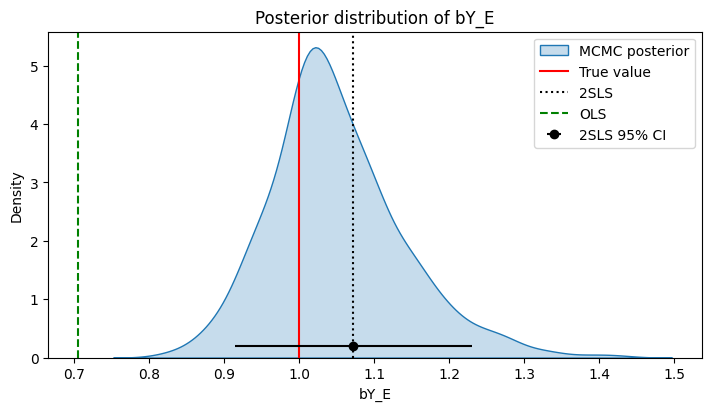

In [12]:
# Plot results using arviz
import seaborn as sns
plt.rcParams['figure.constrained_layout.use'] = True

posterior_bY_E = np.asarray(azMCMC.posterior['bY_E'].values.flatten())

fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(posterior_bY_E, fill=True, ax=ax, label='MCMC posterior')

ax.axvline(
    float(dfres.loc['bY_E', 'true']),
    color='red',
    linestyle='-',
    label='True value'
)
ax.axvline(
    float(dfres.loc['bY_E', '2sls statsmodels']),
    color='black',
    linestyle=':',
    label='2SLS'
)
# Add 2sls confidence interval
ax.errorbar(x=res.params[3], y=0.2, xerr=1.96*res.bse[3], fmt='o', color='black', label='2SLS 95% CI')

ax.axvline(
    float(dfres.loc['bY_E', 'OLS']),
    color='green',
    linestyle='--',
    label='OLS'
)

ax.set_title('Posterior distribution of bY_E')
ax.set_xlabel('bY_E')
ax.set_ylabel('Density')
ax.legend()
plt.show()


In [13]:
dfres

,true,mcmc_mean,OLS,2sls manual,2sls statsmodels
bY_X[0],1.0,0.93284243,0.9268191,0.92582715,0.925827
bY_X[1],1.0,0.93171555,0.941779,0.9134079,0.913408
bY_E,1.0,1.049199,0.7045553,1.072236,1.072236
bY_U,-1.0,1.797647,NaN,NaN,NaN
aE,0.5,0.49463922,NaN,NaN,NaN
aY,0.5,0.47019327,0.62815726,0.4677356,0.467736
bE_Z,1.0,0.98377603,NaN,NaN,NaN
bE_U,1.0,-0.75493616,NaN,NaN,NaN


# Pooled model for the latent variable U

In [14]:
def model_pool_fn(X, Z, E=None, Y=None,pool_U=True):
    
    if pool_U:
        # Pooled prior for latent/unobserved variable U
        U_bar = numpyro.sample("U_bar", 
                        dist.Normal(0, 1))
        U_sigma = numpyro.sample('U_sigma',
                        dist.HalfNormal(1))
        U_pool = numpyro.sample('U_pool', 
                        dist.Normal(0, 1).expand([X.shape[0], 1]))
        U = numpyro.deterministic("U", 
                        U_bar + U_pool * U_sigma)
    else:
        U = numpyro.sample('U', dist.Normal(0, 1).expand([X.shape[0], 1]))
    
    # Prior for coefficients for the E model
    aE = numpyro.sample('aE', dist.Normal(0, 1))
    bE_Z = numpyro.sample('bE_Z', dist.Normal(0, 1))
    bE_U = numpyro.sample('bE_U', dist.Normal(0, 1))
    # Mean of E, given instrument Z
    mu_E =  aE + bE_Z * Z + bE_U * U
    # Prior for std of E
    sigma_E = numpyro.sample('sigma_E', dist.HalfNormal(1))
    
    # Sample E from its distribution, given Z
    E = numpyro.sample('E', dist.Normal(mu_E, sigma_E), obs=E)
    
    # Prior for coefficients for the Y model
    aY = numpyro.sample('aY', dist.Normal(0, 1))
    bY_X = numpyro.sample('bY_X', dist.Normal(0, 1).expand([X.shape[1],1]))
    bY_E = numpyro.sample('bY_E', dist.Normal(0, 1))
    bY_U = numpyro.sample('bY_U', dist.Normal(0, 1))
    # Mean of Y, given X, E, and U
    mu_Y = aY +  X @ bY_X + bY_E * E + bY_U * U
    # Prior for std of Y
    sigma = numpyro.sample('sigma', dist.HalfNormal(1))
    # Sample Y from its distribution, given X, E, and U
    numpyro.sample('Y', dist.Normal(mu_Y, sigma), obs=Y)


In [15]:
mcmc_pool = MCMC(NUTS(model_pool_fn, init_strategy=numpyro.infer.init_to_sample), num_warmup=500, num_samples=500, num_chains=1)
mcmc_pool.run(random.PRNGKey(0), X=X, Z=Z, E=E, Y=Y, pool_U=True)
azMCMC_pool = az.from_numpyro(mcmc_pool)
mcmc_pool.print_summary(0.89)

sample: 100%|██████████| 1000/1000 [01:22<00:00, 12.18it/s, 255 steps of size 2.36e-02. acc. prob=0.94]


                   mean       std    median      5.5%     94.5%     n_eff     r_hat
        U_bar     -0.02      0.58      0.00     -1.02      0.80    457.70      1.00
  U_pool[0,0]      1.98      0.60      2.02      0.99      2.76     68.52      1.02
  U_pool[1,0]      0.80      0.52      0.78     -0.10      1.57    298.32      1.00
  U_pool[2,0]     -1.01      0.50     -1.02     -1.80     -0.26    322.89      1.00
  U_pool[3,0]     -0.98      0.53     -1.02     -1.93     -0.22    568.29      1.00
  U_pool[4,0]      0.99      0.57      0.99      0.12      1.94   1007.15      1.00
  U_pool[5,0]      0.81      0.62      0.83     -0.19      1.73     79.35      1.01
  U_pool[6,0]      0.63      0.53      0.62     -0.19      1.52    582.39      1.00
  U_pool[7,0]     -0.58      0.55     -0.60     -1.43      0.23    821.03      1.00
  U_pool[8,0]      1.26      0.58      1.28      0.34      2.21    320.39      1.01
  U_pool[9,0]     -1.38      0.52     -1.38     -2.19     -0.64   1360.91  

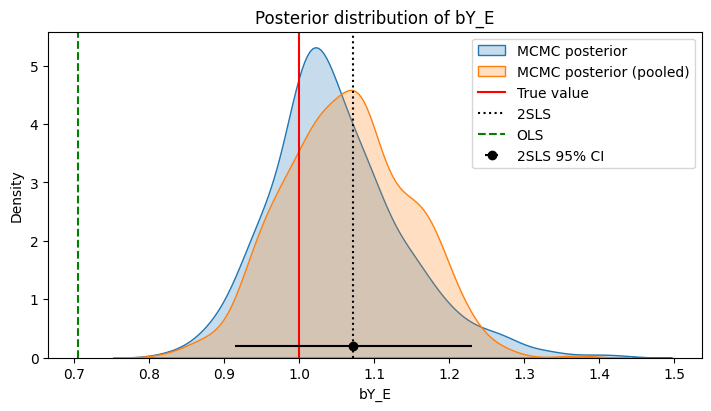

In [17]:
# Plot results using arviz
import seaborn as sns
plt.rcParams['figure.constrained_layout.use'] = True

posterior_bY_E = np.asarray(azMCMC.posterior['bY_E'].values.flatten())
posterior_bY_E_pool = np.asarray(azMCMC_pool.posterior['bY_E'].values.flatten())

fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(posterior_bY_E, fill=True, ax=ax, label='MCMC posterior')

sns.kdeplot(posterior_bY_E_pool, fill=True, ax=ax, label='MCMC posterior (pooled)')

ax.axvline(
    float(dfres.loc['bY_E', 'true']),
    color='red',
    linestyle='-',
    label='True value'
)
ax.axvline(
    float(dfres.loc['bY_E', '2sls statsmodels']),
    color='black',
    linestyle=':',
    label='2SLS'
)
# Add 2sls confidence interval
ax.errorbar(x=res.params[3], y=0.2, xerr=1.96*res.bse[3], fmt='o', color='black', label='2SLS 95% CI')

ax.axvline(
    float(dfres.loc['bY_E', 'OLS']),
    color='green',
    linestyle='--',
    label='OLS'
)

ax.set_title('Posterior distribution of bY_E')
ax.set_xlabel('bY_E')
ax.set_ylabel('Density')
ax.legend()
plt.show()
